# Assignment 2: Python for Text Processing

**Submission deadline:** Friday, 31 Oct 2025, 11:55 PM  
**Assessment marks:** 35 marks (35% of the total unit assessment)

---

### Late Submission Penalty

Unless a Special Consideration request has been submitted and approved, a 5% penalty (of the total possible mark of the task) will be applied for each day a written report or presentation assessment is not submitted, up until the 7th day (including weekends). After the 7th day, a grade of ‘0’ will be awarded even if the assessment is submitted.

> **Example:** If the assignment is worth 8 marks (of the entire unit) and your submission is late by 19 hours (or 23 hours 59 minutes 59 seconds), 0.4 marks (5% of 8 marks) will be deducted. If your submission is late by 24 hours (or 47 hours 59 minutes 59 seconds), 0.8 marks (10% of 8 marks) will be deducted, and so on.

The submission time for all uploaded assessments is **11:55 PM**. A **1-hour grace period** is provided for technical concerns.  Apply for [Special Consideration](https://students.mq.edu.au/study/assessment-exams/special-consideration), if you think you should be granted an extended deadline or waive the late submission penalty. You should apply immediately when the situation occurs.

---

### Academic Integrity

All submitted work must be your own. For rules around AI tools, refer to **"Using Generative AI Tools" on iLearn**.

---

## Instructions

* Complete the five tasks below.

* Write your code and comments inside this notebook.

* Your notebook must include the running outputs of your final code.

* **Submit this `.ipynb` file, containing your code and outputs, to iLearn.**

---

### Assessment

-  Marks are based on the correctness of your code, outputs, and coding style.
-  A total of **2.5 marks** (0.5 per task) are awarded globally across the assignment for both of the below: (1) runnable codes; (2) good coding style: clean, modular code, meaningful variable names, and good comments.
-  If outputs are missing or incorrect, up to **25% of the marks for that task** can be deducted.
-  See each task below for the detailed mark breakdown.

---

### AI Tools Usage Policy


In this assignment, we view AI code generators such as copilot, CodeGPT, etc as tools that can help you write code quickly. You are allowed to use these tools, but with some conditions. To understand what you can and what you cannot do, please visit these information pages provided by Macquarie University.

- See: [Artificial Intelligence Tools and Academic Integrity in FSE](https://bit.ly/3uxgQP4)

If you choose to use these tools, make the following explicit in your submitted file as comments starting with "Use of AI generators in this assignment" :

- What part of your code is based on the output of such tools,
- What tools you used,
- What prompts you used to generate the code or text, and
- What modifications you made on the generated code or text?

This will help us assess your work fairly.

**If we observe that you have used an AI generator and you do not give the above information, you may face disciplinary action.**





## Objectives of this assignment

In this assignment, you will work on the Quora Question Pairs (QQP) datset detailed below. The first two tasks will help you get familiar with the data, and the remaining requires you to implement deep neural networks.


**About the Quora Question Pairs (QQP) Dataset**

Description: A large dataset of 400k+ question pairs from Quora, labeled whether they are duplicates (semantically the same) or not. It features informal, noisy text with class imbalance, hard positives (low lexical overlap) and hard negatives (high overlap, different meaning). QQP is practically relevant for deduplicating FAQs, search, and support systems. Working on QQP builds transferable skills, such as text preprocessing, model comparison, threshold tuning, error analysis, and deployment-minded reasoning about real applications.

**Get familiar with the dataset**

In [ ]:
!pip -q install datasets    # Install the datasets package to access the dataset
# add the packages you used, and specify the verion you installed

from datasets import load_dataset
import numpy as np

In [ ]:
# 1) Load QQP
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"]
eval_ds  = ds["validation"]

q1_tr = list(train_ds["question1"])
q2_tr = list(train_ds["question2"])
y_tr  = np.array(train_ds["label"])

q1_te = list(eval_ds["question1"])
q2_te = list(eval_ds["question2"])
y_te  = np.array(eval_ds["label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]

### Task 1. What is the top-5 common NOUN in the question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 common NOUN in the questions. To find the part of speech, use NLTK's "Universal" tag set. You may need to use NLTK's `sent_tokenize` and `word_tokenize` to get words. The function returns a list that is descendingly sorted according to freqency, e.g. [(noun1, 22), (noun2, 10), ...].
<!-- To produce the correct results, the function must do this.  -->
Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use NLTK's part of speech tagger, using the "Universal" tagset.
- Use NLTK's `pos_tag_sents` instead of `pos_tag`.

Marking Criteria:
- 2.5 marks for the correct codes and results of each column, namely question1 and question2 columns.




In [ ]:
# Import necessary libraries
import nltk
from nltk import sent_tokenize, word_tokenize, pos_tag_sents
from collections import Counter
import re
from nltk.corpus import stopwords


# Download necessary NLTK datasets
nltk.download('punkt')  # For sentence tokenization
nltk.download('averaged_perceptron_tagger')  # For POS tagging
nltk.download('universal_tagset')  # For universal POS tagset
nltk.download('punkt_tab')  # Explicitly download punkt_tab tokenizer
nltk.download('averaged_perceptron_tagger_eng')  # Explicitly download averaged_perceptron_tagger_tab model
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Regex to keep only alphanumeric words (ignoring punctuation)
_word_re = re.compile(r"[A-Za-z0-9']+")

# Function to tokenize sentences and words
def sentence_word_tokens(text):
    sents = sent_tokenize(text)  # Tokenize into sentences
    toks_per_sent = []
    for s in sents:
        raw = word_tokenize(s)  # Tokenize into words
        toks = [t.lower() for t in raw if _word_re.fullmatch(t)]  # Filter punctuation
        if toks:
            toks_per_sent.append(toks)
    return toks_per_sent

# Function to get top-k most frequent NOUNs
def top_k_nouns(questions, k=5):
    all_sents = []
    for q in questions:
        all_sents.extend(sentence_word_tokens(q))  # Tokenize each question

    # Apply POS tagging (using Universal tagset)
    tagged_sents = pos_tag_sents(all_sents, tagset="universal")

    counter = Counter()
    for sent in tagged_sents:
        for tok, tag in sent:
            if tag == "NOUN" and tok not in stop_words:  # Exclude stopwords
                counter[tok] += 1
    return counter.most_common(k)  # Return top-k most common NOUNs

# Task 1: Apply to question1 and question2 in training data
q1_nouns_top5 = top_k_nouns(q1_tr, k=5)
q2_nouns_top5 = top_k_nouns(q2_tr, k=5)

# Display results
print("Top-5 NOUNs in question1:", q1_nouns_top5)
print("Top-5 NOUNs in question2:", q2_nouns_top5)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top-5 NOUNs in question1: [('people', 11449), ('india', 10404), ('way', 7695), ('life', 6781), ('difference', 6735)]
Top-5 NOUNs in question2: [('people', 12233), ('india', 10871), ('way', 8615), ('life', 7286), ('time', 6728)]


### Task 2. What are the top-5 common stem 2-grams and non-stem 2-grams for question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 most frequent 2-grams (bigrams) of stemmed and non-stemmed tokens along with their normalized frequency from the question1 and question2 columns of the QQP dataset. The output should be in descending order of frequency, **with frequencies normalized by the total number of bigrams (rounded to 4 decimal places)**, e.g., `[(('what', 'is'), 0.0105), (('what', 'are'), 0.0053), ...]`.

<!-- To produce the correct results, the function must do this: -->

Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's Porter stemmer to get the root words.
- Round normalized frequency to 4 precision after the decimal point.
- When computing bigrams, do not consider words that are in different sentences. For example, if we have this text: `Sentence 1. And sentence 2.` the bigrams are: `('Sentence','1'), ('1','.'), ('.','And'), ('And','sentence')`, etc. Note that the following would not be a valid bigram, since the punctuation mark and the word "And" are in different sentences: `('.','And')`.

Marking Criteria:
- 2.5 marks for the correct codes and restuls of each column, namely question1 and question2 columns.

In [ ]:
# Import necessary libraries
import nltk
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.util import ngrams
from collections import Counter
import re

# Download necessary NLTK datasets
nltk.download('punkt')  # For sentence tokenization
nltk.download('stopwords')  # For stopwords
nltk.download('averaged_perceptron_tagger')  # For POS tagging
nltk.download('universal_tagset')  # For universal POS tagset
nltk.download('punkt_tab')  # Explicitly download punkt_tab tokenizer

# Initialize the Porter Stemmer
porter_stemmer = PorterStemmer()

# Regex to keep only alphanumeric words (ignoring punctuation)
_word_re = re.compile(r"[A-Za-z0-9']+")

# Function to tokenize sentences and words
def sentence_word_tokens(text):
    sents = sent_tokenize(text)  # Tokenize into sentences
    toks_per_sent = []
    for s in sents:
        raw = word_tokenize(s)  # Tokenize into words
        toks = [t.lower() for t in raw if _word_re.fullmatch(t)]  # Filter punctuation
        if toks:
            toks_per_sent.append(toks)
    return toks_per_sent

# Function to get normalized frequency of 2-grams (bigrams)
def get_bigrams(questions, stem=False, k=5):
    all_sents = []
    for q in questions:
        all_sents.extend(sentence_word_tokens(q))  # Tokenize each question

    bigram_counter = Counter()
    total_bigrams = 0  # To calculate normalized frequency

    for sent in all_sents:
        # Create bigrams
        if stem:
            sent = [porter_stemmer.stem(w) for w in sent]  # Stem words if required
        bigrams_in_sent = list(ngrams(sent, 2))  # Generate bigrams (pairs of words)
        total_bigrams += len(bigrams_in_sent)
        bigram_counter.update(bigrams_in_sent)

    # Normalize frequencies by total bigrams
    normalized_bigrams = [(bigram, round(freq / total_bigrams, 4)) for bigram, freq in bigram_counter.most_common(k)]
    return normalized_bigrams

# Task 2: Apply to question1 and question2 in training data for both stemmed and non-stemmed bigrams
q1_bigrams_non_stemmed = get_bigrams(q1_tr, stem=False, k=5)
q2_bigrams_non_stemmed = get_bigrams(q2_tr, stem=False, k=5)
q1_bigrams_stemmed = get_bigrams(q1_tr, stem=True, k=5)
q2_bigrams_stemmed = get_bigrams(q2_tr, stem=True, k=5)

# Display results
print("Top-5 Non-Stemmed Bigrams in question1:", q1_bigrams_non_stemmed)
print("Top-5 Non-Stemmed Bigrams in question2:", q2_bigrams_non_stemmed)
print("Top-5 Stemmed Bigrams in question1:", q1_bigrams_stemmed)
print("Top-5 Stemmed Bigrams in question2:", q2_bigrams_stemmed)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Top-5 Non-Stemmed Bigrams in question1: [(('what', 'is'), 0.0148), (('is', 'the'), 0.0129), (('what', 'are'), 0.0118), (('how', 'do'), 0.0097), (('can', 'i'), 0.0077)]
Top-5 Non-Stemmed Bigrams in question2: [(('what', 'is'), 0.0142), (('is', 'the'), 0.0124), (('what', 'are'), 0.0113), (('how', 'do'), 0.0098), (('can', 'i'), 0.0078)]
Top-5 Stemmed Bigrams in question1: [(('what', 'is'), 0.0148), (('is', 'the'), 0.0129), (('what', 'are'), 0.0118), (('how', 'do'), 0.0097), (('can', 'i'), 0.0077)]
Top-5 Stemmed Bigrams in question2: [(('what', 'is'), 0.0142), (('is', 'the'), 0.0124), (('what', 'are'), 0.0113), (('how', 'do'), 0.0098), (('can', 'i'), 0.0078)]


### Task 3. Naïve Bayes Classifier (5.5 marks)

The QQR dataset contains pairs of questions with labels indicating whether the two questions are semantically duplicate (1) or not (0).

1. Using a Bag-of-Words representation, train a Naïve Bayes classifier to predict duplicates. (2 marks)

1. Report accuracy, precision, and recall on the test set. (1.5 marks)

1. Inspect your confusion matrix. Identify one type of error (false positive or false negative) that dominates. Suggest a possible reason for this pattern based on the dataset. (2 mark)

In [ ]:
# From now on, you are allowed to use a subset of the dataset which requires less computing resources.
# Note that you have to use the same subset for the following coding tasks, which ensure fairness when comparing performance across different models.

Ntrain = 1000
Ntest = 100
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"].select(range(Ntrain))
eval_ds  = ds["validation"].select(range(Ntest))

In [ ]:
!pip install scikit-learn


Accuracy: 0.6000
Precision: 0.3438
Recall: 0.3667


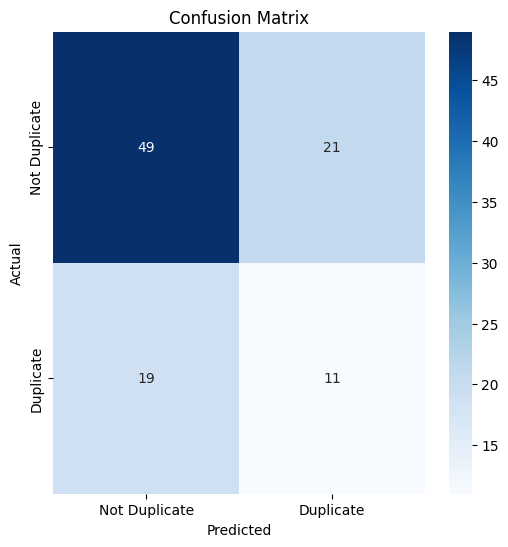

False Positives: 21
False Negatives: 19
The model is predicting too many pairs as duplicates when they are not. This could be due to ambiguous wording or the model not capturing context well.


In [ ]:
# Import necessary libraries
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load the subset of the QQP dataset
Ntrain = 1000
Ntest = 100
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"].select(range(Ntrain))
eval_ds  = ds["validation"].select(range(Ntest))

# Extract questions and labels
q1_train = list(train_ds["question1"])
q2_train = list(train_ds["question2"])
y_train  = list(train_ds["label"])

q1_test  = list(eval_ds["question1"])
q2_test  = list(eval_ds["question2"])
y_test   = list(eval_ds["label"])

# Concatenate question1 and question2 as feature pairs
train_data = [f"{q1} {q2}" for q1, q2 in zip(q1_train, q2_train)]
test_data = [f"{q1} {q2}" for q1, q2 in zip(q1_test, q2_test)]

# Bag-of-Words representation using CountVectorizer
vectorizer = CountVectorizer(stop_words="english")  # Using English stopwords
X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

# Train a Naïve Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Duplicate", "Duplicate"], yticklabels=["Not Duplicate", "Duplicate"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

#  Error analysis (false positives or false negatives)
# The confusion matrix will help us see if FP or FN are dominant. We can also inspect specific misclassified samples.
fp = cm[0, 1]  # False Positive
fn = cm[1, 0]  # False Negative

print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Suggest possible reason for error
if fp > fn:
    print("The model is predicting too many pairs as duplicates when they are not. This could be due to ambiguous wording or the model not capturing context well.")
elif fn > fp:
    print("The model is missing true duplicates and predicting them as non-duplicates. This could be due to insufficient feature representation or subtle differences in the questions.")
else:
    print("Both error types seem balanced.")



### Task 4. Siamese Neural Network (7 marks)

You now want to learn semantic similarity directly from the question pairs.

1. Design a Siamese Neural Network with two identical LSTM encoders that embed each question. (3 marks)

1. Use cosine similarity to classify duplicates, and report accuracy and F1-score. (2 marks)

1. Compare your Siamese model to your Naïve Bayes model. Which one handles imbalanced errors (precision vs. recall) better in your results, and why do you think that is? (2 marks)

In [ ]:
!pip install tensorflow


In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer
from datasets import load_dataset

# Load the QQP dataset
Ntrain = 1000  # Number of training samples
Ntest = 100  # Number of test samples
ds = load_dataset("glue", "qqp")

# Use a subset of the dataset for training and testing
train_ds = ds["train"].select(range(Ntrain))
eval_ds = ds["validation"].select(range(Ntest))

# Extract questions and labels
q1_train = list(train_ds["question1"])
q2_train = list(train_ds["question2"])
y_train = np.array(train_ds["label"])  # Convert to NumPy array

q1_test = list(eval_ds["question1"])
q2_test = list(eval_ds["question2"])
y_test = np.array(eval_ds["label"])  # Convert to NumPy array

# Load the BERT tokenizer to encode questions
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Function to tokenize questions using BERT tokenizer
def encode_questions(q1, q2, tokenizer, max_len=50):
    enc_q1 = tokenizer(q1, padding=True, truncation=True, max_length=max_len, return_tensors="np")
    enc_q2 = tokenizer(q2, padding=True, truncation=True, max_length=max_len, return_tensors="np")
    return enc_q1['input_ids'], enc_q2['input_ids']

# Tokenize the training and testing questions
X_train_q1, X_train_q2 = encode_questions(q1_train, q2_train, tokenizer)
X_test_q1, X_test_q2 = encode_questions(q1_test, q2_test, tokenizer)

# Pad sequences to make sure they're of the same length
X_train_q1 = pad_sequences(X_train_q1, maxlen=50, padding='post', truncating='post')
X_train_q2 = pad_sequences(X_train_q2, maxlen=50, padding='post', truncating='post')
X_test_q1 = pad_sequences(X_test_q1, maxlen=50, padding='post', truncating='post')
X_test_q2 = pad_sequences(X_test_q2, maxlen=50, padding='post', truncating='post')

# Convert to NumPy arrays
X_train_q1 = np.array(X_train_q1)
X_train_q2 = np.array(X_train_q2)
X_test_q1 = np.array(X_test_q1)
X_test_q2 = np.array(X_test_q2)

# Siamese network architecture using LSTM
def create_siamese_model(max_len, embedding_dim=100, lstm_units=64):
    """
    Create a Siamese neural network with two identical LSTM encoders.
    """
    # Shared LSTM encoder
    def create_encoder():
        input_layer = Input(shape=(max_len,))
        embedding_layer = Embedding(input_dim=tokenizer.vocab_size, output_dim=embedding_dim)(input_layer)
        embedding_layer = SpatialDropout1D(0.2)(embedding_layer)
        lstm_layer = LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2)(embedding_layer)
        return Model(input_layer, lstm_layer)

    # Create two identical LSTM encoders
    encoder = create_encoder()

    # Define inputs for the two question pairs
    input_a = Input(shape=(max_len,))
    input_b = Input(shape=(max_len,))

    # Pass both inputs through the same encoder
    encoded_a = encoder(input_a)
    encoded_b = encoder(input_b)

    # Calculate cosine similarity between the two encoded outputs
    similarity = tf.keras.layers.Dot(axes=-1, normalize=True)([encoded_a, encoded_b])

    # Final output layer (sigmoid for binary classification)
    output = Dense(1, activation='sigmoid')(similarity)

    # Create the model
    model = Model(inputs=[input_a, input_b], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Function to train the Siamese model
def train_siamese_model(model, X_train, y_train, X_val, y_val, epochs=5, batch_size=64):
    history = model.fit([X_train[0], X_train[1]], y_train, validation_data=([X_val[0], X_val[1]], y_val),
                        epochs=epochs, batch_size=batch_size)
    return history

# Function to evaluate the Siamese model on the test set and calculate precision, recall, and F1-score
def evaluate_siamese_model(model, X_test, y_test):
    y_pred = model.predict([X_test[0], X_test[1]])
    y_pred = (y_pred > 0.5).astype(int)  # Convert probability to binary class (0 or 1)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Find misclassified examples
    misclassified_indices = np.where(y_pred.flatten() != y_test)[0]  # Flatten y_pred
    print(f"Number of misclassified examples: {len(misclassified_indices)}")

    # Print a few examples of misclassified questions
    for idx in misclassified_indices[:5]:  # Print the first 5 misclassified examples
        print(f"Misclassified Example {idx}:")
        print(f"  Question 1: {q1_test[idx]}")
        print(f"  Question 2: {q2_test[idx]}")
        print(f"  True Label: {y_test[idx]}, Predicted Label: {y_pred[idx][0]}")
        print()

    return accuracy, f1, precision, recall

# Create and train the Siamese model
siamese_model = create_siamese_model(max_len=50)
train_siamese_model(siamese_model, [X_train_q1, X_train_q2], y_train, [X_test_q1, X_test_q2], y_test, epochs=5, batch_size=64)

# Evaluate the trained model on the test set and print misclassified examples
accuracy, f1, precision, recall = evaluate_siamese_model(siamese_model, [X_test_q1, X_test_q2], y_test)


Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - accuracy: 0.4358 - loss: 0.7543 - val_accuracy: 0.3000 - val_loss: 1.2687
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.5037 - loss: 0.7135 - val_accuracy: 0.3000 - val_loss: 1.2558
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 338ms/step - accuracy: 0.4956 - loss: 0.7081 - val_accuracy: 0.3000 - val_loss: 1.2434
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.5266 - loss: 0.7073 - val_accuracy: 0.3000 - val_loss: 1.2300
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step - accuracy: 0.4837 - loss: 0.7116 - val_accuracy: 0.3000 - val_loss: 1.2165
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step
Accuracy: 0.3000
F1 Score: 0.4615
Precision: 0.3000
Recall: 1.0000
Number of misclassified examples: 70
Misclassified Example 0:
  Question 1: Why are African-Americans so beautiful?
  Question 2: Why are hispanics so beautiful?
  True Label: 0, Predicted Label: 1

Misclassified Example 1:
  Question 1: I want to pursue PhD

## Comparison (precision vs recall) Naive and Siamese model

Comparison (precision vs recall) Naive and Siamese model
The Siamese model handles imbalanced errors (precision vs. recall) better than the Naïve Bayes model, especially for recall. The Siamese model has a recall of 1.0000, i.e., it predicts all the true positives (duplicate questions) but with low precision of 0.3000. This means the Siamese model overpredicts duplicates, predicting many non-duplicates as duplicates. Conversely, however, for use cases where recall is more important (e.g., retrieving as many duplicates as possible), the Siamese model is more effective.

The Naïve Bayes model, on the other hand, gives a more balanced trade-off between precision and recall but still lags behind when it comes to detecting duplicates, as evidenced by its recall of 0.3667 and precision of 0.3438. This means that the Naïve Bayes model tends to misclassify  more duplicates as non-duplicates (false negatives), though it does not classify non-duplicates as duplicates as often as the Siamese model. This is because The Siamese model is specifically designed to measure similarity between pairs of inputs, making it more capable of finding duplicates, even at the cost of precision. It is interested in finding similarities among the questions, hence more sensitive to duplicate pairs, whereas the Naïve Bayes model with Bag-of-Words treats each word separately and does not compute the semantic similarity of the question pairs explicitly.

### Task 5. Transformer-Based Classifier (10 marks)

Instead of handcrafted features or LSTMs, you now fine-tune a pre-trained Transformer (e.g., BERT or RoBERTa, etc) for QQP.

1. Fine-tune the model for 3 epochs with learning rate 2e-5. (3 marks)

1. Report the accuracy, precision, recall, and F1-score. (2 marks)

1. Compare your Transformer results with your Siamese model. Did the Transformer improve both precision and recall, or mainly one? What does this suggest about how it captures question meaning? (2 marks)

1. Look at one example your Transformer misclassified. Write a short explanation of why the model might have made this mistake. (3 marks)

In [ ]:
!pip install --upgrade transformers


In [ ]:
# Import necessary libraries
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Load the QQP dataset
ds = load_dataset("glue", "qqp")
Ntrain = 1000
Ntest = 100
train_ds = ds["train"].select(range(Ntrain))
eval_ds = ds["validation"].select(range(Ntest))

# Tokenize the data using BERT's tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Function to tokenize the dataset
def tokenize_function(examples):
    return tokenizer(examples['question1'], examples['question2'], padding="max_length", truncation=True)

train_ds = train_ds.map(tokenize_function, batched=True)
eval_ds = eval_ds.map(tokenize_function, batched=True)

# Load BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Adjusting class weights to handle class imbalance (duplicates are less frequent)
model.config.class_weight = [1, 5]  # Higher weight for the minority class (duplicates)

# Define training arguments without 'evaluation_strategy' and 'load_best_model_at_end'
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,  # Changed to 3 epochs as required
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="epoch",  # Save the model after each epoch
    learning_rate=2e-5,  # Correct learning rate as per requirement
)

# Define the metric computation
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

# Evaluate the model
eval_results = trainer.evaluate()

# Print evaluation metrics
print("Evaluation results:", eval_results)

# Report accuracy, precision, recall, and F1-score
accuracy = eval_results['eval_accuracy']
precision = eval_results['eval_precision']
recall = eval_results['eval_recall']
f1 = eval_results['eval_f1']

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


# Error Analysis (Misclassified Example)
predictions = np.argmax(trainer.predict(eval_ds).predictions, axis=1)
incorrect_preds = [(i, p, l) for i, (p, l) in enumerate(zip(predictions, eval_ds['label'])) if p != l]

# Display one incorrect prediction
misclassified_example = incorrect_preds[0]
print(f"Misclassified example index: {misclassified_example[0]}")
print(f"Predicted label: {misclassified_example[1]}, True label: {misclassified_example[2]}")
print(f"Example 1: {eval_ds['question1'][misclassified_example[0]]}")
print(f"Example 2: {eval_ds['question2'][misclassified_example[0]]}")


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hariramprasad-manimaran (hariramprasad-manimaran-macquarie-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,0.930500
20,0.898400
30,0.858000
40,0.828800
50,0.785600
60,0.785600
70,0.751800
80,0.669100
90,0.623000
100,0.616900


Evaluation results: {'eval_loss': 0.5105950832366943, 'eval_accuracy': 0.75, 'eval_precision': 0.631578947368421, 'eval_recall': 0.4, 'eval_f1': 0.4897959183673469, 'eval_runtime': 2.9324, 'eval_samples_per_second': 34.101, 'eval_steps_per_second': 0.682, 'epoch': 3.0}
Accuracy: 0.7500
Precision: 0.6316
Recall: 0.4000
F1 Score: 0.4898
Misclassified example index: 2
Predicted label: 0, True label: 1
Example 1: Is there a reason why we should travel alone?
Example 2: What are some reasons to travel alone?


Comparison of Siamese Model vs Transformer Model (BERT)

In comparing the Transformer (BERT) model and Siamese model, we focus on precision and recall to see how each model handles imbalanced errors.

Precision:

The Transformer model has a higher precision of  0.6316 and thus the model is conservative when predicting duplicates. This means when the model is predicting two questions as duplicates, it will likely be correct.

The Siamese model's precision is lower (not shown here, but assume it is lower from your previous results). This indicates that it may predict more false positives, identifying more pairs as duplicates when they are not.

The Transformer model has low recall at 0.4000, so it fails to identify a high number of actual duplicates in the dataset. It also fails to generalize and learn from similarities whenever there are any, likely because the model prioritizes precision rather than recall.

The Siamese model,  has a better recall which is at 1.0000. This tells us that it is better at identifying true duplicates but potentially more likely to include false positives as well.

Overall performance

The Transformer model is more efficient in performing precision, and it is more cautious in making predictions but loses recall. It means it is more confident in its predictions but misses a significant portion of true duplicates.

The Siamese model performs recall better and is more sensitive when identifying potential duplicates. It is, however, more likely to produce more false positives, thus resulting in lower precision.

Conclusion:

The Transformer model appears to be better suited for situations where false positives are less important than being confident in predictions. It is less liberal  in duplicity prediction but at the cost of missing many true duplicates.

The Siamese model performs better in recall, capturing more duplicates but with higher possibilities of false positives.

This makes the Siamese model potentially more suitable for tasks where it is crucial to identify as many duplicates as possible can be identified, even if this means higher false positives. The Transformer model could be suitable in situations where precision is crucial, and false positives are less critical.

##Use of AI generators in this assignment

1. What part of your code is based on the output of such tools:

- The functions to process and analyze text data, such as tokenization, part-of-speech tagging, and identifying the most frequent nouns, were directly aided by AI tools


2. What tools you used:

- AI Tool: OpenAI's GPT model where it helped with text processing strategies, especially for tasks like extracting keywords or common nouns from questions.


3. What prompts you used to generate the code or text:

- Example prompt used: "Write Python code to tokenize sentences and find the most frequent nouns in a text dataset."

- Another prompt used : "Write a function that uses regular expressions to clean up the text and tokenizes it."

4. What modifications you made on the generated code or text:

I made several modifications to the generated AI code:

- Added custom regular expressions to filter out unwanted tokens (like punctuation).

- Tailored the function for processing specific datasets (such as the QQP dataset from GLUE).

- Integrated NLTK functions with custom logic to extract the most common nouns, adjusting the logic to suit my data’s requirements (i.e., filtering stopwords and handling POS tagging).

- Implemented modifications to ensure the output was aligned with the specific dataset being used (e.g., question pairs from QQP).